In [1]:
# verify if the environment (MALT) is correct and node 
import sys
print(sys.executable)

import socket
print(socket.gethostname())

/exports/csce/eddie/inf/groups/ajitha_project/piyush/.conda/envs/MALT/bin/python3.9
node2i23.ecdf.ed.ac.uk


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import sklearn
import os
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook'
import plotly.graph_objects as go
import pandas as pd

import itertools

import matplotlib.pyplot as plt


In [11]:
model_ls = [
    'llava-1.5-7b', 
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B', 
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    'VstarBench'
]

path = f'{os.getcwd()}/../../results/'

dfs = []
for ds_name in ds_names:
    results_dict = {
        'Model': model_ls,
        'accuracy': [],
        'accuracy_withoutImg': [],
        # 'AUC_diff': []
    }

    print(ds_name)
    for ax_idx, model in enumerate(model_ls):
        
        
        #### Calculate Accuracy - withIMG
        path = f'{os.getcwd()}/../../results//{model}/'
        files = os.listdir(f'{path}/')
        for file in files:
            # if ds_name == 'MATE':
            #     prediction_df = pd.read_csv(f'{path}/{file}')
            if ds_name == 'ScienceQA':
                if '.csv' in file and ds_name in file and 'withoutHint_' in file and 'corrected' not in file:
                    prediction_df = pd.read_csv(f'{path}/{file}')
            else:  
                if '.csv' in file and ds_name in file and 'without' not in file and 'corrected' not in file:
                    prediction_df = pd.read_csv(f'{path}/{file}')
                    
        if ds_name == 'MATE':
            if model=='llava-1.5-7b':
                results_dict['accuracy'] = results_dict['accuracy'] + [len(prediction_df[prediction_df['prediction_lower']==prediction_df['gold_reference_lower']])/len(prediction_df)]  
            else:
               results_dict['accuracy'] = results_dict['accuracy'] + [len(prediction_df[prediction_df['prediction_lower']==prediction_df['gold_reference_formatted']])/len(prediction_df)]
        else:
            results_dict['accuracy'] = results_dict['accuracy'] + [len(prediction_df[prediction_df['prediction']==prediction_df['gold_reference']])/len(prediction_df)]

            
        #### Calculate Accuracy - withoutIMG
        path = f'{os.getcwd()}/../../results//{model}/'
        files = os.listdir(f'{path}/')
        for file in files:
            if ds_name=='ScienceQA':
                if '.csv' in file and ds_name in file and 'withoutHintwithoutImg' in file and 'corrected' not in file:
                    prediction_woimg_df = pd.read_csv(f'{path}/{file}')
            else:
                if '.csv' in file and ds_name in file and 'withoutImg' in file and 'corrected' not in file:
                    prediction_woimg_df = pd.read_csv(f'{path}/{file}')
        
        if ds_name=='MATE':
            # results_dict['accuracy_withoutImg'] = [0.0]*len(model_ls),
            if model=='llava-1.5-7b':
                results_dict['accuracy_withoutImg'] = results_dict['accuracy_withoutImg'] + [len(prediction_woimg_df[prediction_woimg_df['prediction_lower']==prediction_woimg_df['gold_reference_lower']])/len(prediction_woimg_df)]  
            else:
               results_dict['accuracy_withoutImg'] = results_dict['accuracy_withoutImg'] + [len(prediction_woimg_df[prediction_woimg_df['prediction_lower']==prediction_woimg_df['gold_reference_formatted']])/len(prediction_woimg_df)]
        else:
            results_dict['accuracy_withoutImg'] = results_dict['accuracy_withoutImg'] + [len(prediction_woimg_df[prediction_woimg_df['prediction']==prediction_woimg_df['gold_reference']])/len(prediction_woimg_df)]
            
    results_df = pd.DataFrame(results_dict)
    results_df['accuracy_diff'] = results_df['accuracy'] - results_df['accuracy_withoutImg']
    results_df['ds_name'] = [ds_name]*len(model_ls)
    
    dfs = dfs + [results_df]

dfs = pd.concat(dfs)


MATE
ScienceQA
MicroVQA
MathVision
HallusionBench
BLINK
VstarBench


In [12]:
fontsize = 16
fontsize_minor = 12

model_names_mapper = {
    'llava-1.5-7b': 'LLaVA1.5-Vicuna-7B', 
    'llava-v1.6-vicuna-7b': 'LLaVA1.6-Vicuna-7B', 
    'llava-v1.6-mistral-7b': 'LLaVA1.6-Mistral-7B', 
    'molmoD-7B': 'MolmoD-7B', 
    'Qwen2.5-VL-3B': 'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B': 'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct': 'Qwen3-VL-Instruct-4B',
    'Qwen3-VL-8B-Instruct': 'Qwen3-VL-Instruct-8B',

}

marker_map = {
    "MATE": "o",            # circle
    "ScienceQA": "s",        # square
    "MicroVQA": "^",         # triangle up
    "MathVision": "D",       # diamond
    "HallusionBench": "X",   # bold cross
    "BLINK": "P",            # plus-filled
    "VstarBench": "*",       # star
}

dfs['model_corrected'] = [model_names_mapper[i] for i in dfs['Model']]

/tmp/ipykernel_3932761/2683625316.py:17: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3932761/2683625316.py:24: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



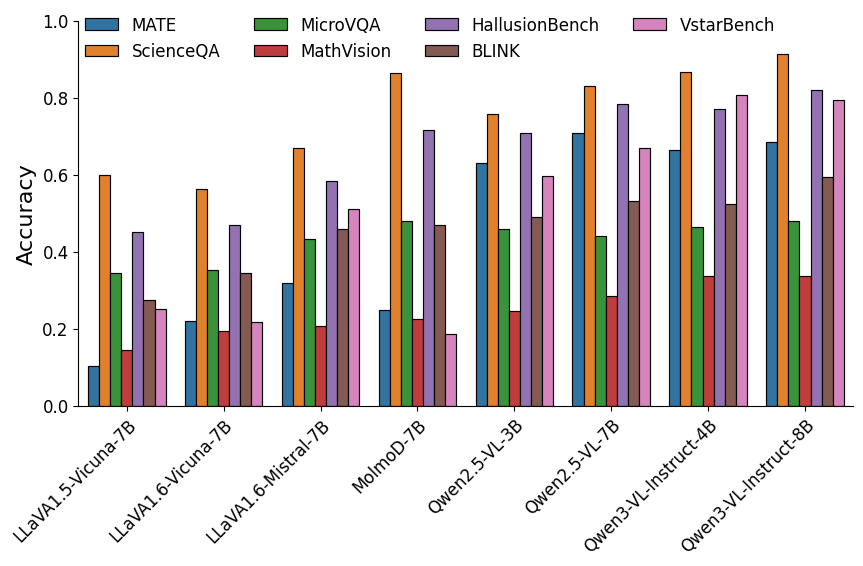

In [13]:
fig, ax = plt.subplots(1,1,figsize=(10,5))


b = sns.barplot(
    data=dfs,
    x='model_corrected', 
    y='accuracy',
    ax=ax,
    hue='ds_name',
    edgecolor="black",
    linewidth=0.85,
)

    
b.set_xlabel('', fontsize=fontsize)
b.set_ylabel('Accuracy', fontsize=fontsize)
b.set_xticklabels(
    b.get_xticklabels(), 
    fontsize=fontsize_minor,
    rotation=45,
    ha="right", 
    rotation_mode="anchor",
)
b.set_yticklabels(
    b.get_yticklabels(), 
    fontsize=fontsize_minor,
)

b.set(ylim=(0, 1))
b.legend(
    loc=(0,0.88),
    frameon=False, 
    ncols=int(len(model_ls)/2),
    fontsize=fontsize_minor,
)
sns.despine(top=True, right=True)

fig.savefig(
    "./../Figures/vlm_performance.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

/tmp/ipykernel_3932761/480779062.py:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3932761/480779062.py:25: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



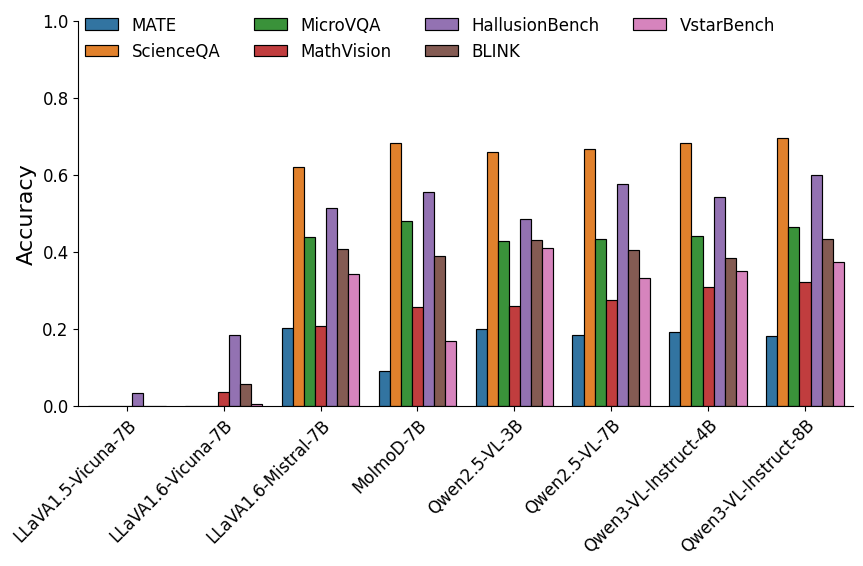

In [14]:
fig, ax = plt.subplots(1,1,figsize=(10,5))

b = sns.barplot(
    data=dfs,
    x='model_corrected', 
    y='accuracy_withoutImg',
    ax=ax,
    hue='ds_name',
    edgecolor="black",
    linewidth=0.85,
)


b.set(ylim=(0, 1))
    
b.set_xlabel('', fontsize=fontsize)
b.set_ylabel('Accuracy', fontsize=fontsize)
b.set_xticklabels(
    b.get_xticklabels(), 
    fontsize=fontsize_minor,
    rotation=45,
    ha="right", 
    rotation_mode="anchor",
)
b.set_yticklabels(
    b.get_yticklabels(), 
    fontsize=fontsize_minor,
)


b.legend(
    loc=(0,0.88),
    frameon=False, 
    ncols=int(len(model_ls)/2),
    fontsize=fontsize_minor,
)
sns.despine(top=True, right=True)

fig.savefig(
    "./../Figures/vlm_woimg_performance.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

/tmp/ipykernel_3801478/2152582697.py:27: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3801478/2152582697.py:34: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



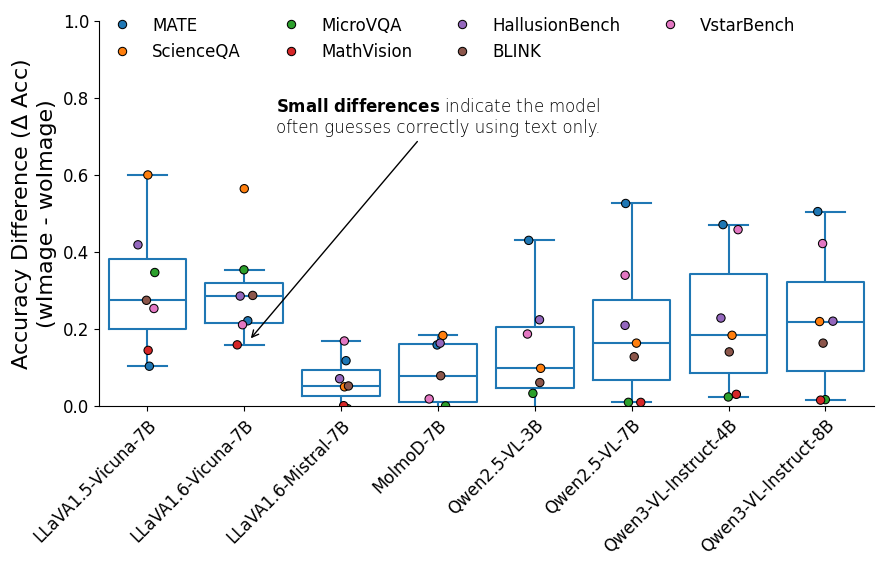

In [25]:
fig, ax = plt.subplots(1,1,figsize=(10,5))

b = sns.boxplot(
    data=dfs,
    x='model_corrected', 
    y='accuracy_diff',
    fill=False,
    ax=ax,
    showfliers=False
)

sns.stripplot(
    data=dfs,
    x='model_corrected', 
    y='accuracy_diff',
    ax=b,
    hue='ds_name',
    edgecolor="black",
    linewidth=0.75,
    size=6
)

b.set(ylim=(0, 1))

b.set_xlabel('', fontsize=fontsize)
b.set_ylabel('Accuracy Difference ($\Delta$ Acc) \n(wImage - woImage)', fontsize=fontsize)
b.set_xticklabels(
    b.get_xticklabels(), 
    fontsize=fontsize_minor,
    rotation=45,
    ha="right", 
    rotation_mode="anchor",
)
b.set_yticklabels(
    b.get_yticklabels(), 
    fontsize=fontsize_minor,
)

b.legend(
    loc=(0,0.88),
    frameon=False, 
    ncols=int(len(model_ls)/2),
    fontsize=fontsize_minor,
)

sns.despine(top=True, right=True)


# x-axis order from plot (robust)
x_order = [t.get_text() for t in ax.get_xticklabels()]

# largest value
y_idx = dfs['accuracy_diff'].max().item()
x_model = dfs[dfs['accuracy_diff']==y_idx]['model_corrected'].item()
x_idx = x_order.index(x_model)

ax.annotate(
        (
        r"$\bf{Small\ differences}$ indicate the model"
        "\n"
        "often guesses correctly using text only."
    ),
    xy=(x_idx+1.05, 0.15+0.02),
    xytext=(x_idx + 3, y_idx + 0.15),
    arrowprops=dict(
        arrowstyle="->", 
        linewidth=1,
        connectionstyle="arc3,rad=0" ,
        # relpos=(1, 0.5)
    ),
    fontsize=12,
    fontweight=299,
    ha="center",
    va="center",
)


fig.savefig(
    "./../Figures/vlm_diff_performance.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

In [18]:
dfs

,Model,accuracy,accuracy_withoutImg,accuracy_diff,ds_name,model_corrected
0,llava-1.5-7b,0.103091,0.000000,0.103091,MATE,LLaVA1.5-Vicuna-7B
1,llava-v1.6-vicuna-7b,0.221091,0.000000,0.221091,MATE,LLaVA1.6-Vicuna-7B
2,llava-v1.6-mistral-7b,0.320182,0.202727,0.117455,MATE,LLaVA1.6-Mistral-7B
3,molmoD-7B,0.249636,0.091273,0.158364,MATE,MolmoD-7B
4,Qwen2.5-VL-3B,0.629818,0.199818,0.430000,MATE,Qwen2.5-VL-3B
5,Qwen2.5-VL-7B,0.709455,0.183636,0.525818,MATE,Qwen2.5-VL-7B
6,Qwen3-VL-4B-Instruct,0.664182,0.193273,0.470909,MATE,Qwen3-VL-Instruct-4B
7,Qwen3-VL-8B-Instruct,0.685818,0.181091,0.504727,MATE,Qwen3-VL-Instruct-8B
0,llava-1.5-7b,0.599901,0.000000,0.599901,ScienceQA,LLaVA1.5-Vicuna-7B
1,llava-v1.6-vicuna-7b,0.564204,0.000000,0.564204,ScienceQA,LLaVA1.6-Vicuna-7B


In [ ]:
# fig = go.Figure()

# for model in model_ls:
#     sub = dfs[dfs["Model"] == model]

#     # close the polygon explicitly
#     r = list(sub["accuracy"]) + [sub["accuracy"].iloc[0]]
#     theta = list(sub["ds_name"]) + [sub["ds_name"].iloc[0]]

#     fig.add_trace(go.Scatterpolar(
#         r=r,
#         theta=theta,
#         mode="lines+markers",
#         name=model,
#         fill="none",
#         line=dict(width=3),   
#         marker=dict(size=6),
#     ))

# fig.update_layout(
#     polar=dict(radialaxis=dict(range=[0, 1], tickfont=dict(size=10))),
#     legend=dict(orientation="h", y=-0.2),
# )
# fig.show()


In [5]:
# fig = go.Figure()

# for model in model_ls:
#     sub = dfs[dfs["Model"] == model]

#     # close the polygon explicitly
#     r = list(sub["accuracy"]) + [sub["accuracy"].iloc[0]]
#     theta = list(sub["ds_name"]) + [sub["ds_name"].iloc[0]]

#     fig.add_trace(go.Scatterpolar(
#         r=r,                   # ✅ use closed r
#         theta=theta,           # ✅ use closed theta
#         mode="lines+markers",
#         name=model,
#         opacity=0.5,
#         line=dict(width=4),
#         marker=dict(size=8),
#         fill="none",
#     ))

# fig.update_layout(
#     width=900,
#     height=900,
#     polar=dict(
#         radialaxis=dict(range=[0, 1], tickfont=dict(size=14)),
#         angularaxis=dict(tickfont=dict(size=20)),
#     ),
#     legend=dict(
#         orientation="h",
#         y=-0.1,
#         x=0.5,
#         font=dict(size=14),
#     ),
#     margin=dict(l=80, r=80, t=80, b=120),
# )

# fig.show()


In [9]:
model_ls = [
    # "molmoD-7B",
    "llava-1.5-7b",
    # "Qwen3-VL-4B-Instruct",
    # "Qwen3-VL-8B-Instruct",
    # "Qwen2.5-VL-3B",
    # "Qwen2.5-VL-7B",
    # "llava-v1.6-mistral-7b",
    # "llava-v1.6-vicuna-7b"
]

ds_names = [
    'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    'VstarBench'
]

for ds_name in ds_names:
    for model_name in model_ls:
        current_dir = '/exports/csce/eddie/inf/groups/ajitha_project/piyush/MALT/MALT/'
        # ds_name = 'MATE'
        experiment_tag = 'withoutHint_' if ds_name=='ScienceQA' else ''
        
        # Read prediction files and remove idx that perform same
        predictions_wImg_df = pd.read_csv(f"{current_dir}/results/{model_name}/{model_name}_{experiment_tag}{ds_name}_prediction.csv")
        predictions_wImg_df = predictions_wImg_df.rename(columns={"Unnamed: 0": "idx_main"})
        if ds_name=='ScienceQA':
            predictions_wImg_df = predictions_wImg_df.rename(columns={"grade": "tag"})
        if ds_name=='MATE':
            predictions_wImg_df['tag'] = predictions_wImg_df['object_count']
        
        experiment_tag = 'withoutHintwithoutImg_' if ds_name=='ScienceQA' else 'withoutImg_'
        predictions_woImg_df = pd.read_csv(f"{current_dir}/results/{model_name}/{model_name}_{experiment_tag}{ds_name}_prediction.csv")
        predictions_woImg_df = predictions_woImg_df.rename(columns={"Unnamed: 0": "idx_main"})
        if ds_name=='ScienceQA':
            predictions_woImg_df = predictions_woImg_df.rename(columns={"grade": "tag"})
        if ds_name=='MATE':
            predictions_woImg_df['tag'] = predictions_woImg_df['object_count']
        
        
        merged_df = predictions_wImg_df.merge(
            predictions_woImg_df,
            on='idx_main',
            suffixes=['wImg', 'woImg']
        )
        
        # merged_df = merged_df[
        #     ~((merged_df['predictionwoImg']==merged_df['gold_referencewoImg']) &
        #     (merged_df['predictionwImg']==merged_df['gold_referencewImg'])) 
        # ].reset_index(drop=True)
        
        merged_df = merged_df[
            merged_df['predictionwImg']!=merged_df['predictionwoImg']
        ].reset_index(drop=True)
        
        merged_df.to_csv(f"{current_dir}/results/{model_name}/{model_name}_{ds_name}_prediction_corrected.csv")
        
        print(model_name,len(merged_df))

llava-1.5-7b 5500
llava-1.5-7b 2002
llava-1.5-7b 430
llava-1.5-7b 1286
llava-1.5-7b 311
llava-1.5-7b 667
llava-1.5-7b 115


In [22]:
merged_df

,idx_main,imagewImg,outputwImg,predictionwImg,gold_referencewImg,object_countwImg,prediction_lowerwImg,gold_reference_lowerwImg,gold_reference_formattedwImg,tagwImg,imagewoImg,outputwoImg,predictionwoImg,gold_referencewoImg,object_countwoImg,prediction_lowerwoImg,gold_reference_lowerwoImg,gold_reference_formattedwoImg,tagwoImg
0,0,7e8a39cbce31181466491620a63de934.png,USER: \n USER: \nThis image shows a minimalis...,Object_0,"{""answer"": ""Object_7""}",9,object_0,"{""answer"": ""object_7""}",object_7,9,NaN,USER: \n USER: \nThis image shows a minimalis...,NaN,"{""answer"": ""Object_7""}",9,NaN,"{""answer"": ""object_7""}",object_7,9
1,1,4b69b6eb323f926d21cd7b4d3aa6cf94.png,USER: \n USER: \nThis image shows a minimalis...,Object_0,"{""answer"": ""Object_0""}",10,object_0,"{""answer"": ""object_0""}",object_0,10,NaN,USER: \n USER: \nThis image shows a minimalis...,NaN,"{""answer"": ""Object_0""}",10,NaN,"{""answer"": ""object_0""}",object_0,10
2,2,60b990927b64079fa61f9fb9591d6994.png,USER: \n USER: \nThis image shows a minimalis...,Object_2,"{""answer"": ""Object_1""}",6,object_2,"{""answer"": ""object_1""}",object_1,6,NaN,USER: \n USER: \nThis image shows a minimalis...,NaN,"{""answer"": ""Object_1""}",6,NaN,"{""answer"": ""object_1""}",object_1,6
3,3,ddfc53034f0a421970051e98c9dc6139.png,USER: \n USER: \nThis image shows a minimalis...,blue,"{""answer"": ""gray""}",6,blue,"{""answer"": ""gray""}",gray,6,NaN,USER: \n USER: \nThis image shows a minimalis...,NaN,"{""answer"": ""gray""}",6,NaN,"{""answer"": ""gray""}",gray,6
4,4,ee3ed5c55c080eeed55ca2b2a24d7285.png,USER: \n USER: \nThis image shows a minimalis...,Object_0,"{""answer"": ""Object_4""}",7,object_0,"{""answer"": ""object_4""}",object_4,7,NaN,USER: \n USER: \nThis image shows a minimalis...,NaN,"{""answer"": ""Object_4""}",7,NaN,"{""answer"": ""object_4""}",object_4,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,5495,a7386765d625fbdcdb1b99eee7daaf51.png,USER: \n USER: \nThis image shows a minimalis...,CYLINDER,"{""answer"": ""cone""}",3,cylinder,"{""answer"": ""cone""}",cone,3,NaN,USER: \n USER: \nThis image shows a minimalis...,NaN,"{""answer"": ""cone""}",3,NaN,"{""answer"": ""cone""}",cone,3
5496,5496,271618ad987006f91d6e4a0cb66ac0b1.png,USER: \n USER: \nThis image shows a minimalis...,45.33533477783203,"{""answer"": 67.65984344482422}",8,45.33533477783203,"{""answer"": 67.65984344482422}",67.65984344482422,8,NaN,USER: \n USER: \nThis image shows a minimalis...,NaN,"{""answer"": 67.65984344482422}",8,NaN,"{""answer"": 67.65984344482422}",67.65984344482422,8
5497,5497,51c762d0d4421ba2249f9655daf6d016.png,USER: \n USER: \nThis image shows a minimalis...,green,"{""answer"": ""yellow""}",8,green,"{""answer"": ""yellow""}",yellow,8,NaN,USER: \n USER: \nThis image shows a minimalis...,NaN,"{""answer"": ""yellow""}",8,NaN,"{""answer"": ""yellow""}",yellow,8
5498,5498,ec795e2594e154873f2c53b519fbb728.png,USER: \n USER: \nThis image shows a minimalis...,blue,"{""answer"": ""blue""}",4,blue,"{""answer"": ""blue""}",blue,4,NaN,USER: \n USER: \nThis image shows a minimalis...,NaN,"{""answer"": ""blue""}",4,NaN,"{""answer"": ""blue""}",blue,4


In [3]:

model_name = 'Qwen2.5-VL-3B'
ds_name = 'VstarBench'
current_dir = '/exports/csce/eddie/inf/groups/ajitha_project/piyush/MALT/MALT/'

df = pd.read_csv(f'{current_dir}/results/{model_name}/svd/{ds_name}_svd_effective_rank_corrected.csv')
df

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,idx_corrected,idx_main,outputwImg,predictionwImg,gold_referencewImg,tagwImg,outputwoImg,predictionwoImg,gold_referencewoImg,tagwoImg
0,0,80.268660,95.739840,90.930640,90.942990,93.346800,97.149920,101.688130,109.038740,110.100395,...,40,145,system\nYou are a helpful assistant.\nuser\n Q...,1,1,relative_position,system\nYou are a helpful assistant.\nuser\n Q...,1,1,relative_position
1,1,81.721760,92.826190,89.540870,89.172690,90.626976,92.334180,94.032330,99.027250,99.535835,...,7,26,system\nYou are a helpful assistant.\nuser\n Q...,2,2,direct_attributes,system\nYou are a helpful assistant.\nuser\n Q...,2,2,direct_attributes
2,2,94.462630,115.831740,109.040110,109.006930,110.905100,113.779230,116.835950,124.362680,123.686940,...,1,3,system\nYou are a helpful assistant.\nuser\n Q...,1,1,direct_attributes,system\nYou are a helpful assistant.\nuser\n Q...,1,1,direct_attributes
3,3,82.686330,102.006170,96.183970,96.279880,98.747070,102.031030,105.368020,111.898990,116.328950,...,47,155,system\nYou are a helpful assistant.\nuser\n Q...,1,1,relative_position,system\nYou are a helpful assistant.\nuser\n Q...,1,1,relative_position
4,4,83.211430,100.237656,94.089690,94.411260,97.373540,102.690790,108.138160,115.759630,118.681170,...,17,65,system\nYou are a helpful assistant.\nuser\n Q...,1,1,direct_attributes,system\nYou are a helpful assistant.\nuser\n Q...,1,1,direct_attributes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,45,25.825857,35.616566,37.320717,38.300816,39.834710,40.685684,41.111996,40.913180,40.131874,...,28,115,system\nYou are a helpful assistant.\nuser\n Q...,1,1,relative_position,system\nYou are a helpful assistant.\nuser\n Q...,1,1,relative_position
196,46,25.074331,34.796448,36.491450,37.549465,39.085766,40.023070,40.532265,40.482628,39.884880,...,31,118,system\nYou are a helpful assistant.\nuser\n Q...,1,1,relative_position,system\nYou are a helpful assistant.\nuser\n Q...,1,1,relative_position
197,47,24.329330,34.888992,36.405178,37.432343,38.959713,39.784330,40.237040,40.495167,40.074745,...,16,61,system\nYou are a helpful assistant.\nuser\n Q...,1,1,direct_attributes,system\nYou are a helpful assistant.\nuser\n Q...,1,1,direct_attributes
198,48,27.308723,36.997650,38.682210,39.660694,41.077110,41.774883,42.163230,41.940815,41.601040,...,48,156,system\nYou are a helpful assistant.\nuser\n Q...,1,1,relative_position,system\nYou are a helpful assistant.\nuser\n Q...,1,1,relative_position
